# CMPINF 2100: Midterm exam

## Jean Fernandes


You will demonstrate your ability to merge, group, summarize, visualize, and find patterns in data. This exam uses data associated with a manufacturing example. 

**Please read through the midterm instructions on Coursera before filling in this notebook.** These instructions present an important overview of the goals, considerations, input CSV files, and variables within the data is provided in the instructions on Coursera. The input files should be saved to the same folder as this notebook in order to load them.

You may add as many markdown and code cells as you see fit to answer questions below. For visualizations, include markdown cells stating what you see in the figures and why you selected to use them.

## Import modules

You are permitted to use the following modules on this exam.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

You are **NOT** permitted to use any other modules or functions. However, you **ARE** permitted to create your own user-defined functions if you would like.

## Problem 1




### 1a)
The file names for the 3 machine data sets are provided as strings in the cell below. You are required to read in the CSV files and assign the data to the `m01_df`, `m02_df`, and `m03_df` objects. The data from machine 1 will therefore be associated with `m01_df`, machine 2 is associated with `m02_df`, and machine 3 is associated with `m03_df`.  

In [2]:
# Define the files for the 3 machine level CSV files

file_m01 = 'midterm_machine_01.csv'

file_m02 = 'midterm_machine_02.csv'

file_m03 = 'midterm_machine_03.csv'

In [3]:
# Read in the CSV files and name them accordingly

m01_df = pd.read_csv(file_m01)

m02_df = pd.read_csv(file_m02)

m03_df = pd.read_csv(file_m03)

### 1b)
In this problem you will explore each of the three machine data sets. 
Perform the following **ESSENTIAL** activities:

* How many rows and columns are in each data set? 
* What are the names and data types for each column?
* How many unique values are there for each column?
* How many missing values are there for each column?

In [4]:
print('Rows and Columns')
for df, name in zip([m01_df, m02_df, m03_df], ['m01_df', 'm02_df', 'm03_df']):
    print('\n Shape: ', df.shape)

Rows and Columns

 Shape:  (5152, 7)

 Shape:  (5119, 7)

 Shape:  (4458, 7)


In [5]:
for df, name in zip([m01_df, m02_df, m03_df], ['m01_df', 'm02_df', 'm03_df']):
    print('\n', name)
    df.info()


 m01_df
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5152 entries, 0 to 5151
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      5152 non-null   object 
 1   Batch   5152 non-null   int64  
 2   s_id    5152 non-null   int64  
 3   x1      5152 non-null   float64
 4   x2      5152 non-null   float64
 5   x3      5152 non-null   float64
 6   x4      5152 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 281.9+ KB

 m02_df
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5119 entries, 0 to 5118
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      5119 non-null   object 
 1   Batch   5119 non-null   int64  
 2   s_id    5119 non-null   int64  
 3   x1      5119 non-null   float64
 4   x2      5119 non-null   float64
 5   x3      5119 non-null   float64
 6   x4      5119 non-null   float64
dtypes: float64(4), int64(2), object(1)


In [6]:
print("Unique Values for each column")
for df, name in zip([m01_df, m02_df, m03_df], ['m01_df', 'm02_df', 'm03_df']):
    print('\n', name)
    print(df.nunique())


Unique Values for each column

 m01_df
ID       5152
Batch      50
s_id      149
x1       5152
x2       5152
x3       5152
x4       5152
dtype: int64

 m02_df
ID       5119
Batch      50
s_id      133
x1       5119
x2       5119
x3       5119
x4       5119
dtype: int64

 m03_df
ID       4458
Batch      41
s_id      141
x1       4458
x2       4458
x3       4458
x4       4458
dtype: int64


In [7]:
print('Missing values for each colum')
for df, name in zip([m01_df, m02_df, m03_df], ['m01_df', 'm02_df', 'm03_df']):
    print('\n', df.isnull().sum())

Missing values for each colum

 ID       0
Batch    0
s_id     0
x1       0
x2       0
x3       0
x4       0
dtype: int64

 ID       0
Batch    0
s_id     0
x1       0
x2       0
x3       0
x4       0
dtype: int64

 ID       0
Batch    0
s_id     0
x1       0
x2       0
x3       0
x4       0
dtype: int64


### 1c)
Concatenate the 3 machine datasets into a single dataframe with a new column, `machine_id`, that indicates the correct index value for that machine (1, 2, or 3). Name the single dataframe `machine_df`.


In [8]:
# Concatenate the 3 DataFrames into a single DataFrame which includes the `machine_id` variable
m01_df['machine_id'] = 1
m02_df['machine_id'] = 2
m03_df['machine_id'] = 3

machine_df = pd.concat([m01_df, m02_df, m03_df], ignore_index=True) 

In [9]:
machine_df.sample()

,ID,Batch,s_id,x1,x2,x3,x4,machine_id
5234,B001-M02-S083,1,83,49.45829,98.840293,22.000295,13.857674,2


### 1d)
Using either the combined or separate machine datasets, calculate the following:
* How many unique values for `Batch` are associated with each MACHINE (data set)?

In [10]:
machine_df.groupby('machine_id')['Batch'].nunique()

machine_id
1    50
2    50
3    41
Name: Batch, dtype: int64

### 1e)
Finally, visually explore the MARGINAL behavior, i.e. the distributions of single variables in the combined dataset (except for the `ID` variable). You must use visualizations appropriate for the DATA TYPE of the columns.

In [11]:
machine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14729 entries, 0 to 14728
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          14729 non-null  object 
 1   Batch       14729 non-null  int64  
 2   s_id        14729 non-null  int64  
 3   x1          14729 non-null  float64
 4   x2          14729 non-null  float64
 5   x3          14729 non-null  float64
 6   x4          14729 non-null  float64
 7   machine_id  14729 non-null  int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 920.7+ KB


In [12]:
# from the midterm instructions on coursera batch is cat
# exclude ID, s_id

categorical_variables = ['Batch', 'machine_id']
numerical_variables = ['x1', 'x2', 'x3', 'x4']

Distribution of Categorical Variables


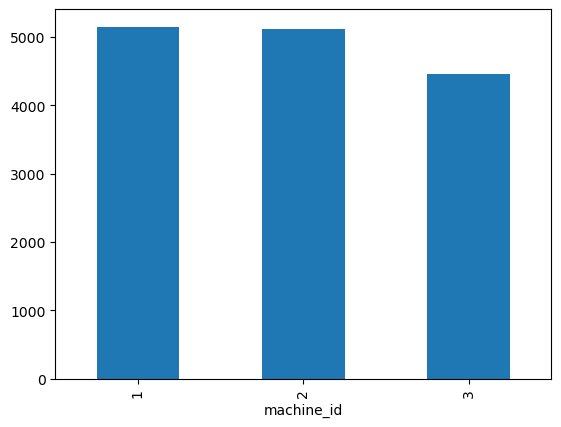

In [13]:
print("Distribution of Categorical Variables")
for col in categorical_variables:
    machine_df[col].value_counts().plot(kind='bar')

Note: I am not sure why `batch` did not print. Maybe too many categories?

<Axes: xlabel='Batch'>

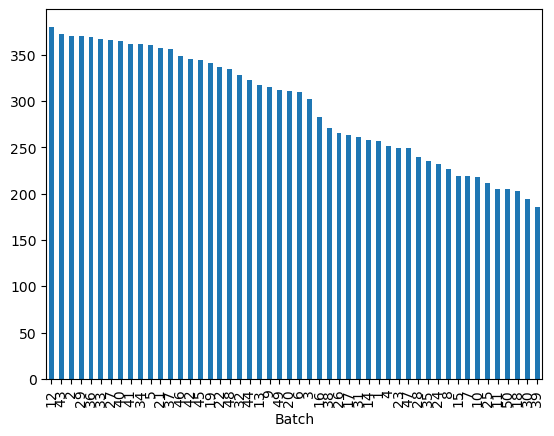

In [14]:
machine_df['Batch'].value_counts().plot(kind='bar')

Distribution of Numerical Variables


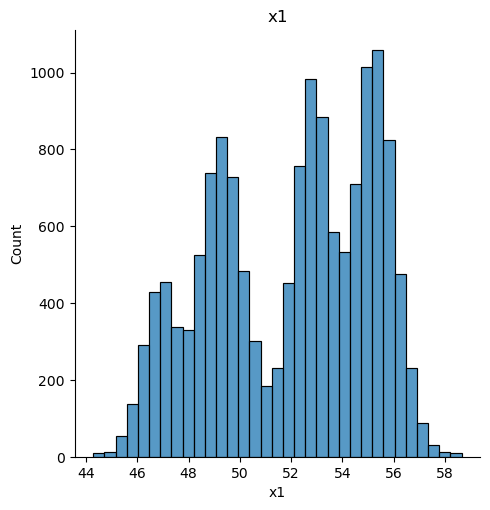

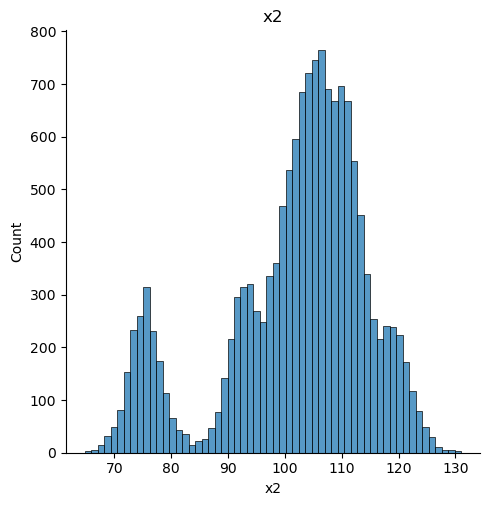

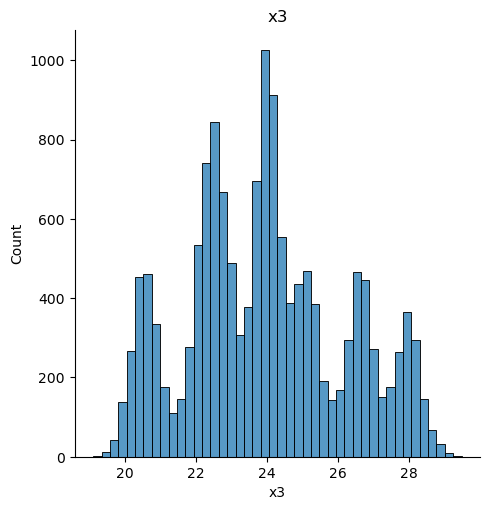

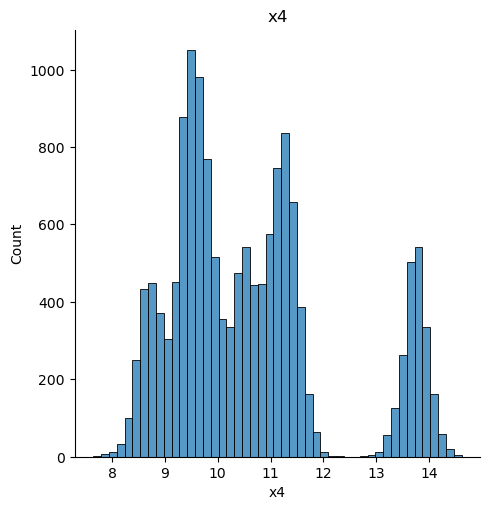

In [15]:
print("Distribution of Numerical Variables")
for col in numerical_variables:
    sns.displot(data=machine_df, x=col, kind='hist')
    plt.title(col)
    plt.show()

### 1f)
Instructional content has covered one way of representing categorical-to-continuous relationships: boxplots. Use boxplots as visualizations to answer the following question:

* Does the distribution (summary statistics) of the OPERATING VARIABLES `x1` through `x4` vary across the three MACHINES?

The distribution of the operating variables is faily similar across the three machines, with only minor variation. 

Boxplot of Numerical Variables


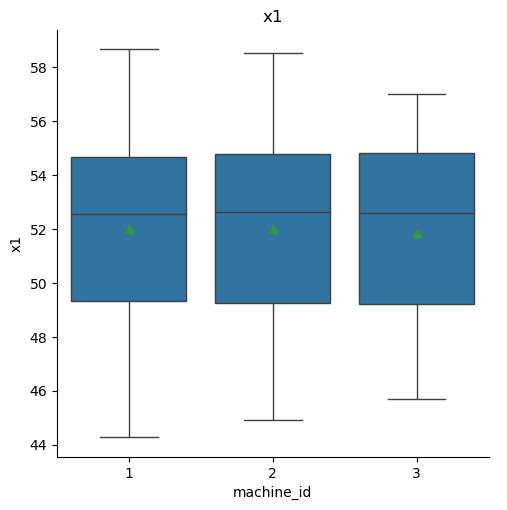

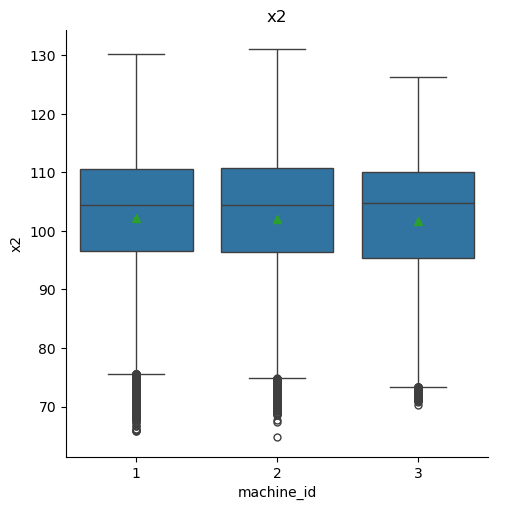

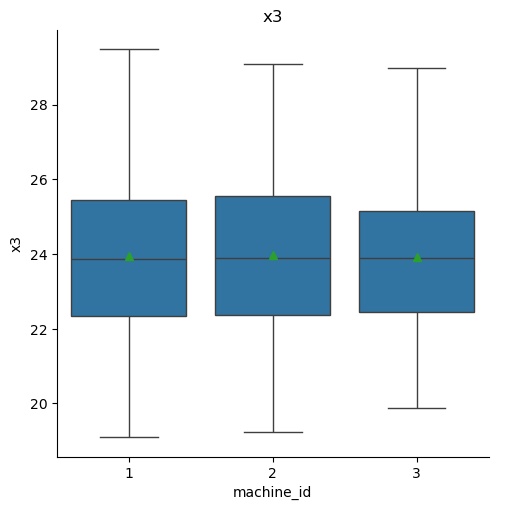

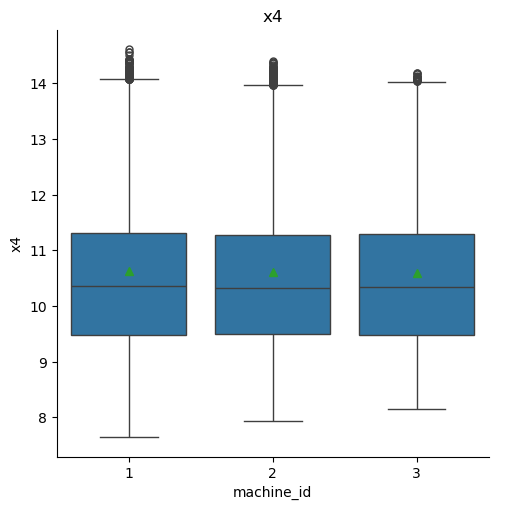

In [16]:
print("Boxplot of Numerical Variables")
for col in numerical_variables:
    sns.catplot(data=machine_df, x='machine_id', y=col, kind='box', showmeans=True)
    plt.title(col)
    plt.show()

### 1g)
For every machine, calculate the exact mean value for every operating variable.

In [17]:
machine_df.groupby('machine_id')[numerical_variables].mean().reset_index()

,machine_id,x1,x2,x3,x4
0,1,51.998218,102.207011,23.947216,10.628436
1,2,51.989377,101.998905,23.982312,10.605275
2,3,51.857672,101.650057,23.927679,10.602371


## Problem 2

### 2a)
The supplier batch data set file name is provided for you below. Read in the CSV file and assign the data set to the `batch_df` object. 

In [18]:
# define the batch supplier file
batch_file = 'midterm_supplier.csv'

In [19]:
# read in the batch supplier data set

batch_df = pd.read_csv(batch_file)
batch_df.head()

,Batch,Supplier,Density
0,1,B,10.388587
1,2,A,9.296880
2,3,A,9.565636
3,4,B,10.005387
4,5,A,9.339177


### 2b)
Perform the following **ESSENTIAL** activities:

* How many rows and columns are in the data? 
* What are the names and data types for each column?
* How many unique values are there for each column?
* How many missing values are there for each column?

In [20]:
batch_df.shape

(50, 3)

In [21]:
batch_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Batch     50 non-null     int64  
 1   Supplier  50 non-null     object 
 2   Density   50 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.3+ KB


In [22]:
batch_df.nunique()

Batch       50
Supplier     2
Density     50
dtype: int64

In [23]:
batch_df.isnull().sum()

Batch       0
Supplier    0
Density     0
dtype: int64

### 2c)
Visually explore the MARGINAL behavior of the variables in the data. Use visualizations appropriate for the kind of variables the columns are, taking into account the data type and your contextual knowledge of the dataset.

<Axes: xlabel='Batch'>

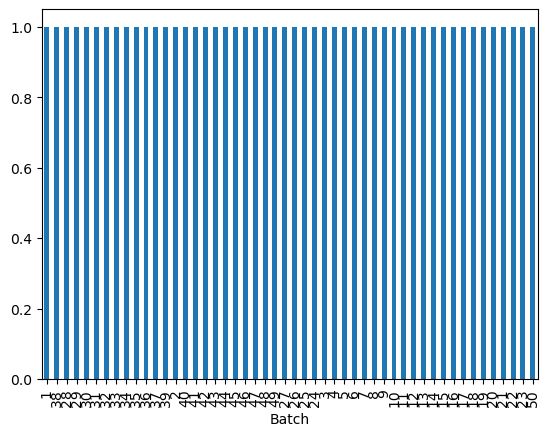

In [24]:
# from the coursera page batch is a cat variable cat
batch_df['Batch'].value_counts().plot(kind='bar')

Supplier Count Plot


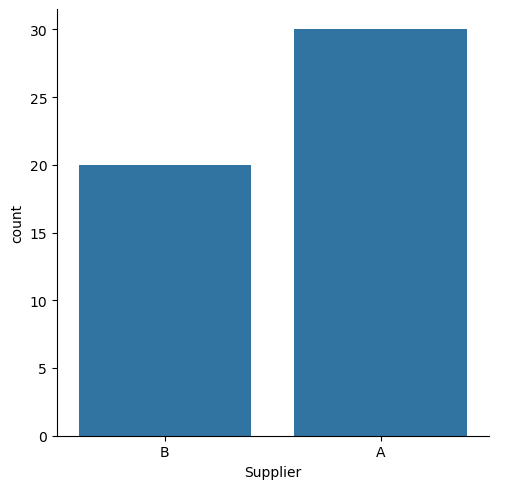

In [25]:
print("Supplier Count Plot")
sns.catplot(data=batch_df, x='Supplier', kind="count")

<Axes: >

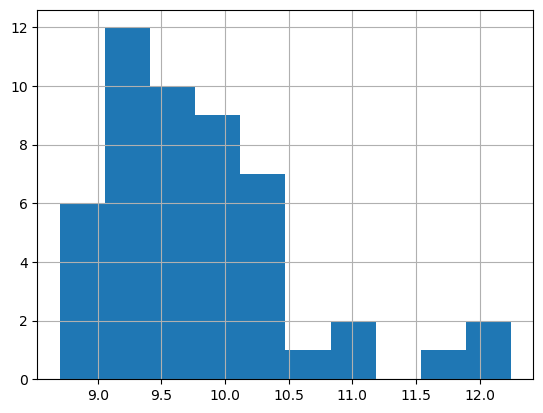

In [26]:
batch_df['Density'].hist()

### 2d)
Use boxplots as visualizations to address the following question:
* Does the distribution (summary statistics) of `Density` depend on the `Supplier`?

Yes, there is a noticeable difference on the distribution of Density across both suppliers. 

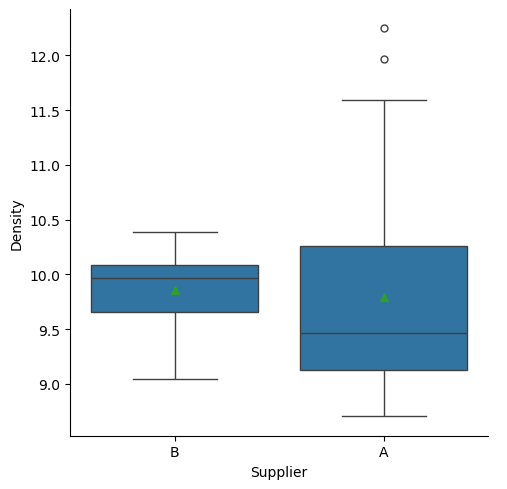

In [27]:
sns.catplot(data=batch_df, x='Supplier', y='Density', kind='box', showmeans=True)
plt.show()

### 2e)
Now it's time to join (merge) the `batch_df` DataFrame with the `machine_df` DataFrame. Assign the merged DataFrame to the `dfa` DataFrame.

In [28]:
# merge the batch supplier data set with the (concatenated) machine data set

dfa = pd.merge(machine_df, batch_df, on='Batch') 
dfa.sample(5)

,ID,Batch,s_id,x1,x2,x3,x4,machine_id,Supplier,Density
14190,B044-M03-S063,44,63,48.334969,90.459810,22.575636,10.402628,3,A,9.090145
2011,B020-M01-S091,20,91,49.621144,90.535991,22.943767,10.629385,1,B,9.720199
1037,B011-M01-S018,11,18,45.262110,78.140838,26.132273,9.650639,1,A,9.176533
9508,B043-M02-S123,43,123,47.164300,82.269904,27.134790,9.447986,2,A,9.624945
617,B007-M01-S046,7,46,55.213120,123.240703,28.177206,9.833483,1,A,9.695526


In [96]:
dfa[['Batch','Supplier','Density']].describe()

,Batch,Density
count,14729.000000,14729.000000
mean,26.066196,9.735339
std,14.490825,0.729389
min,1.000000,8.703627
25%,13.000000,9.289811
50%,27.000000,9.624945
75%,39.000000,10.083865
max,50.000000,12.246089


### 2f)
You can now explore the relationships between the MACHINE OPERATIONAL VARIABLES and the SUPPLIERS! Use boxplots to explore the following relationship:
* Explore if the distribution of the 4 OPERATING VARIABLES `x1` through `x4` vary by the `Supplier`.



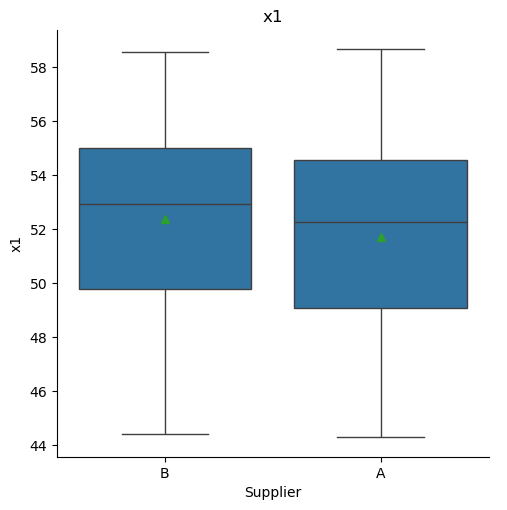

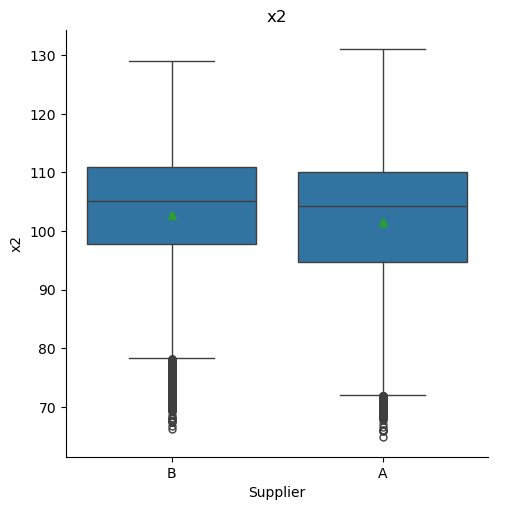

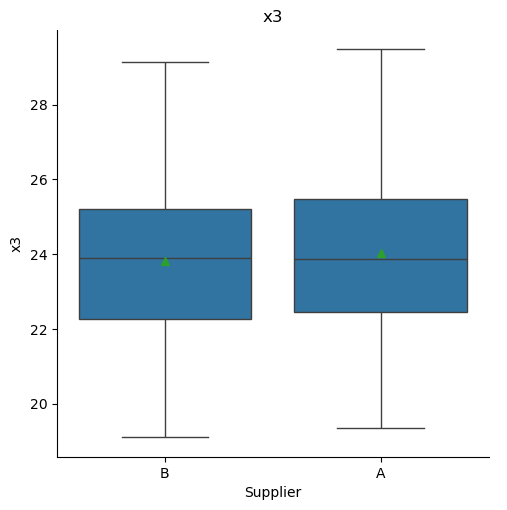

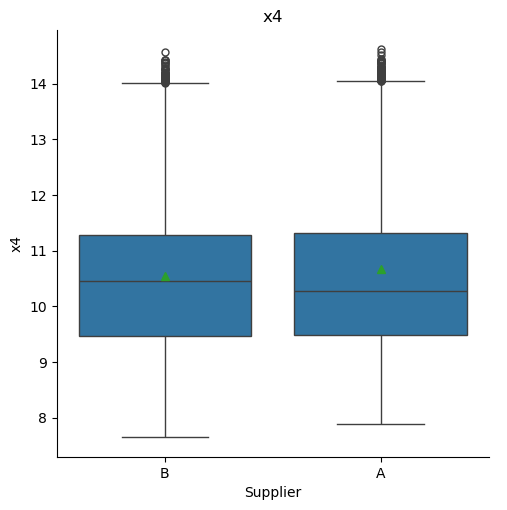

In [29]:
for col in ['x1', 'x2', 'x3', 'x4']:
    sns.catplot(data=dfa, x='Supplier', y=col, kind='box', showmeans=True)
    plt.title(col)
    plt.show()

## Problem 3

### 3a)
The DROP TEST result data set file name is provided for you below. Read in the CSV file and assign the dataset to the `test_df` object. 

In [30]:
# define the test data set file name
test_file = 'midterm_test.csv'

In [31]:
# read in the test data set

test_df = pd.read_csv(test_file)
test_df.head()

,ID,test_group_id,Result
0,B001-M01-S056,A-0,1
1,B001-M01-S002,A-0,1
2,B001-M01-S049,A-0,1
3,B001-M01-S030,A-0,0
4,B001-M01-S048,A-0,1


### 3b)
Perform the following **ESSENTIAL** activities:

* How many rows and columns are in the data? 
* What are the names and data types for each column?
* How many unique values are there for each column?
* How many missing values are there for each column?

In [32]:
test_df.shape

(1412, 3)

In [33]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1412 entries, 0 to 1411
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             1412 non-null   object
 1   test_group_id  1412 non-null   object
 2   Result         1412 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 33.2+ KB


In [34]:
test_df.nunique()

ID               1412
test_group_id     141
Result              2
dtype: int64

In [35]:
test_df.isnull().sum()

ID               0
test_group_id    0
Result           0
dtype: int64

### 3c)
Explore the MARGINAL behavior of the variables in the data other than ID (identifier) columns. 

* For categorical variables with a manageable number of, visualize the number of rows per unique value.
* For categorical variables with too many unique values to visualize, calculate information about the number of rows per unique value. It's not necessary to show the number of rows for every unique value, but rather more general information about the range and distribution of rows per unique value. 

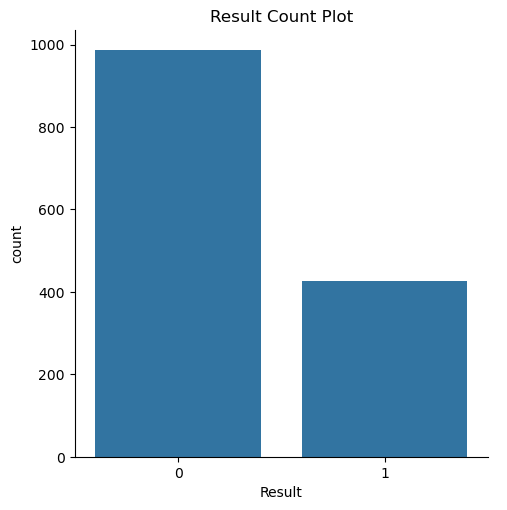

In [36]:
sns.catplot(data=test_df, x='Result', kind="count")
plt.title("Result Count Plot")
plt.show()

In [92]:
test_df.columns

Index(['ID', 'test_group_id', 'Result'], dtype='object')

In [95]:
test_df['test_group_id'].value_counts().describe()

count    141.000000
mean      10.014184
std        1.945639
min        5.000000
25%        9.000000
50%       10.000000
75%       11.000000
max       14.000000
Name: count, dtype: float64

In [37]:
dfa.shape

(14729, 10)

In [38]:
test_df.shape

(1412, 3)

### 3d)

Now it's time to JOIN/MERGE the `test_df` DataFrame with the `dfa` DataFrame. Assign the merged DataFrame to the `dfb` DataFrame. 
Answer the following:
* How many rows remain using the DEFAULT joining procedure?


Inner join matches the rows when using the ON parameter so since it found one test for every ID the rows remain the same 1412.

In [39]:
# merge test_df with the dfa object

dfb = pd.merge(dfa, test_df, on='ID')
dfb.shape

(1412, 12)

## Problem 4

Examine the merged `dfb` object and answer the following questions.

### 4a)
* Visualize the number of times each unique value of `Result` occurs for each value of `machine_id`.
* For each value of `machine_id`, calculate the proportion of times the cell phone case failed the test.

*HINT*: Remember that a FAILED test is encoded as `Result == 1`. How can you calculate the PROPORTION of times `Result == 1`?


In [40]:
dfb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1412 entries, 0 to 1411
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             1412 non-null   object 
 1   Batch          1412 non-null   int64  
 2   s_id           1412 non-null   int64  
 3   x1             1412 non-null   float64
 4   x2             1412 non-null   float64
 5   x3             1412 non-null   float64
 6   x4             1412 non-null   float64
 7   machine_id     1412 non-null   int64  
 8   Supplier       1412 non-null   object 
 9   Density        1412 non-null   float64
 10  test_group_id  1412 non-null   object 
 11  Result         1412 non-null   int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 132.5+ KB


<Axes: xlabel='machine_id'>

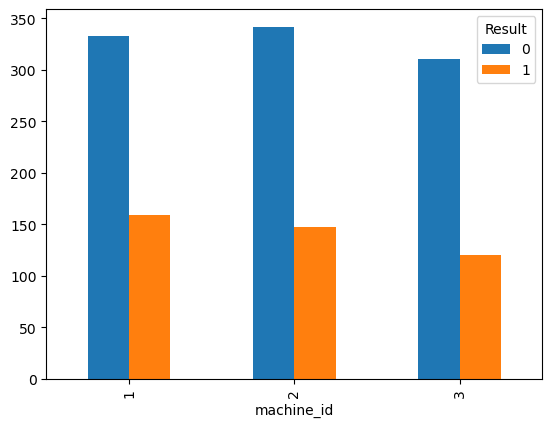

In [41]:
# reference: unstack() https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.unstack.html

dfb.groupby(['machine_id', 'Result'])['Result'].count().unstack().plot(kind='bar')

In [42]:
# proportion
dfb.groupby('machine_id')['Result'].mean()

machine_id
1    0.323171
2    0.300613
3    0.278422
Name: Result, dtype: float64

### 4b)
* Visualize the number of times each unique value of `Result` occurs for each value of `Supplier`.
* For each unique value of `Supplier`, calculate the PROPORTION of times the cell phone case failed the test.

<Axes: xlabel='Supplier'>

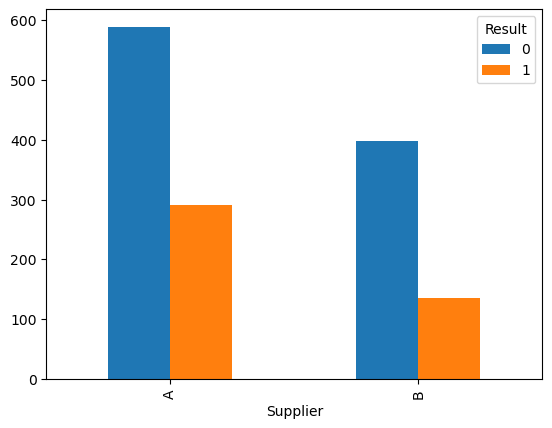

In [43]:
dfb.groupby(['Supplier', 'Result'])['Result'].count().unstack().plot(kind='bar')

In [44]:
# proportion
dfb.groupby('Supplier')['Result'].mean()

Supplier
A    0.330296
B    0.254682
Name: Result, dtype: float64

### 4c)
* Visualize the summary statistics (distribution) of `Density` for each value of `Result`
* Calculate the average `Density` and standard error for each value of `Result`

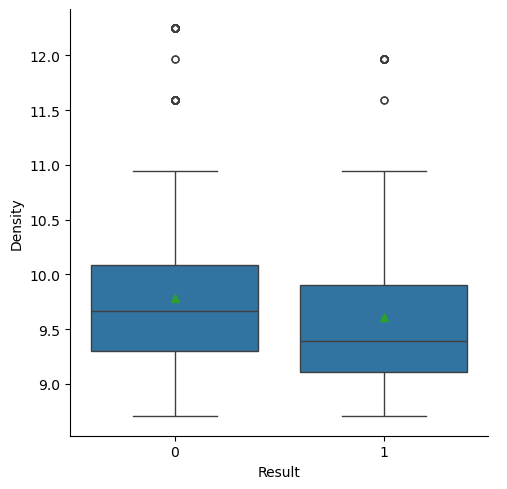

In [45]:
sns.catplot(data=dfb, x='Result', y='Density', kind='box', showmeans=True)

In [46]:
# Average Density
dfb['Density'].mean()

9.732236095408616

In [47]:
# standard error for each value of Result
dfb.groupby('Result')['Density'].sem()

Result
0    0.023381
1    0.033871
Name: Density, dtype: float64

### 4d)
For each operating variable, visualize the distribution for each value of `Result`. This is regardless of which machine.

In [48]:
dfb.columns

Index(['ID', 'Batch', 's_id', 'x1', 'x2', 'x3', 'x4', 'machine_id', 'Supplier',
       'Density', 'test_group_id', 'Result'],
      dtype='object')

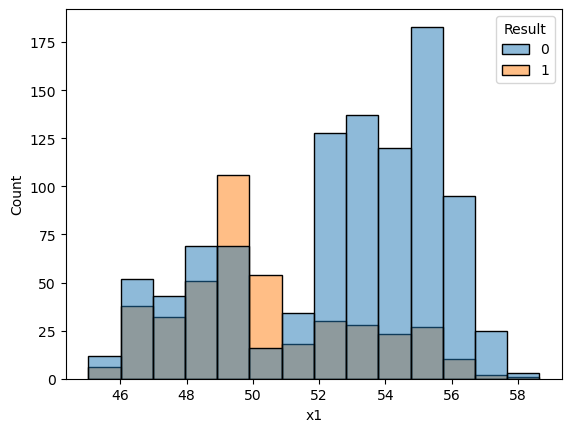

In [49]:
sns.histplot(data=dfb, x='x1', hue='Result')
plt.show()

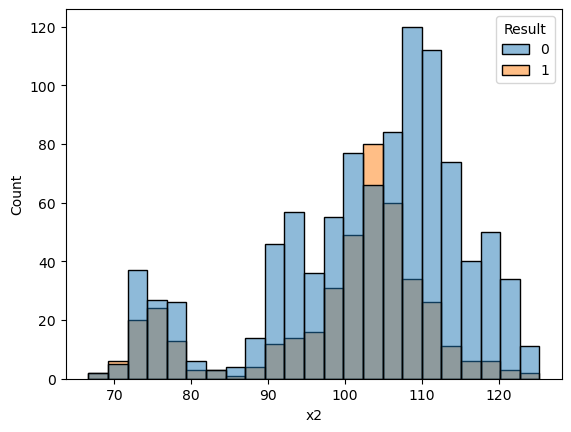

In [50]:
sns.histplot(data=dfb, x='x2', hue='Result')
plt.show()

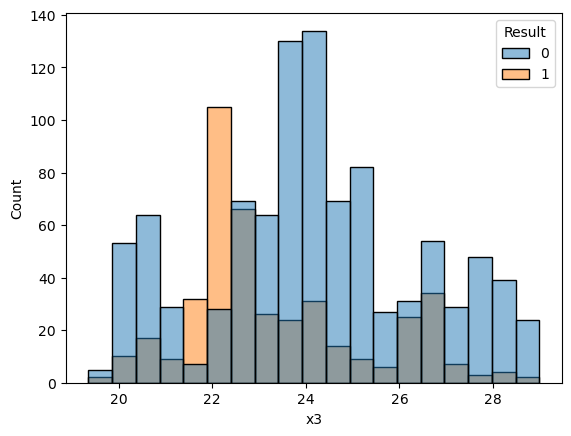

In [51]:
sns.histplot(data=dfb, x='x3', hue='Result')
plt.show()


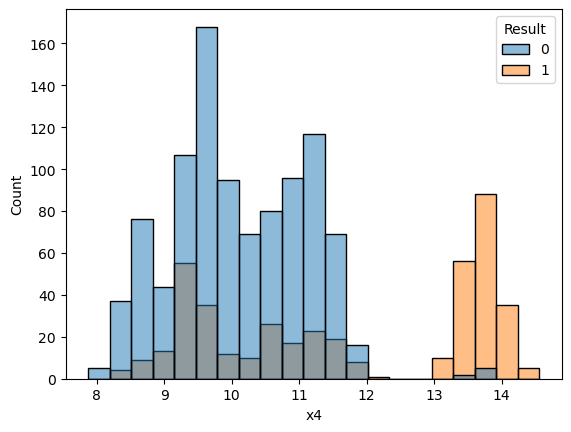

In [52]:
sns.histplot(data=dfb, x='x4', hue='Result')
plt.show()

### 4e)
What kinds of associations with failed drop tests does your analysis suggest?

- x1 Has lower values associated with failueres.
- X3 has also shows lower values associated with failures.
- X2 has the largest overlap (grey area) while the others show clearer separation. Also x2 has the smallest overall failed tests (orange area). 
- x4 has the smallest range of failed tests. However, around 13-14 the failure is very likely.


In [70]:
list_x = ['x1', 'x2', 'x3', 'x4']

In [90]:
dfb['x2'].sample(5)

1291    102.825958
1350     73.416514
918      96.221366
2       109.445722
99      101.115969
Name: x2, dtype: float64

In [88]:
dfb.groupby('Result')['x3'].count()

Result
0    986
1    426
Name: x3, dtype: int64